# Random Forest Classifier

#### This notebook applies Random Forest Classifier to predict whether a basketball player is a good free throw shooter (GoodFT).

#### Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

#### Random Forest was chosen because it handles non-linear relationships well and reduces overfitting through ensemble learning.

#### It also provides feature importance, which helps in understanding which features influence free throw performance.

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("cleaned_data.csv")

df.head()

,G,GS,MP,FG%,3P%,2P%,eFG%,TRB,AST,STL,BLK,TOV,PF,GoodFT,Pos_PF,Pos_PG,Pos_SF,Pos_SG
0,78.0,78.0,36.1,0.519,0.200,0.523,0.520,7.4,4.6,2.2,1.8,3.6,2.7,1,False,False,True,False
1,82.0,82.0,38.3,0.502,0.000,0.504,0.502,14.5,1.8,1.0,1.3,3.7,2.6,0,False,False,False,False
2,82.0,82.0,35.8,0.505,0.333,0.506,0.506,8.8,2.4,1.1,0.7,2.0,2.3,1,False,False,False,False
3,82.0,82.0,34.2,0.523,0.000,0.525,0.523,7.2,1.1,0.9,0.9,2.1,3.2,1,False,False,True,False
4,82.0,82.0,36.2,0.482,0.194,0.489,0.484,3.4,4.8,2.4,0.5,2.2,2.0,1,False,True,False,False


In [16]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = rf.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.680672268907563


In [21]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.68      0.67      1920
           1       0.70      0.69      0.69      2126

    accuracy                           0.68      4046
   macro avg       0.68      0.68      0.68      4046
weighted avg       0.68      0.68      0.68      4046



In [22]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[1297  623]
 [ 669 1457]]


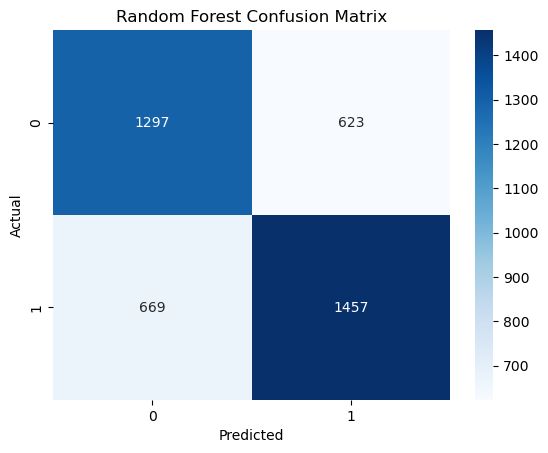

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

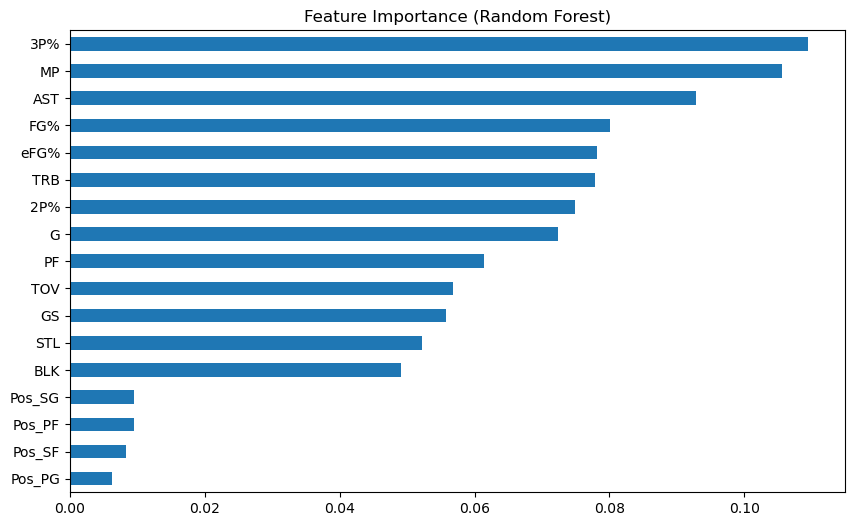

In [24]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [26]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.680672268907563
